# 1.2 Merged Table EDA

Exploratory data analysis for the `eaglei_outages_*_merged.csv` files.

These tables contain individual outage events with county-level detail.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load all merged files and concatenate
data_dir = Path("../../data/raw/introduction/Outage_Dataset")
merged_files = list(data_dir.glob("*_merged.csv"))

print(f"Found {len(merged_files)} merged files")
for f in sorted(merged_files):
    print(f"  - {f.name}")

Found 10 merged files
  - eaglei_outages_2014_merged.csv
  - eaglei_outages_2015_merged.csv
  - eaglei_outages_2016_merged.csv
  - eaglei_outages_2017_merged.csv
  - eaglei_outages_2018_merged.csv
  - eaglei_outages_2019_merged.csv
  - eaglei_outages_2020_merged.csv
  - eaglei_outages_2021_merged.csv
  - eaglei_outages_2022_merged.csv
  - eaglei_outages_2023_merged.csv


In [3]:
# Load and combine all merged data
dfs = [pd.read_csv(f) for f in merged_files]
df = pd.concat(dfs, ignore_index=True)

print(f"Total rows: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Total rows: 1,385,389

Columns: ['fips', 'state', 'county', 'start_time', 'duration', 'min_customers', 'max_customers', 'mean_customers']


,fips,state,county,start_time,duration,min_customers,max_customers,mean_customers
0,1001,Alabama,Autauga,2022-01-03 04:00:00,5.75,452.0,723.0,583.478261
1,1001,Alabama,Autauga,2022-01-08 20:30:00,0.75,406.0,615.0,475.666667
2,1001,Alabama,Autauga,2022-01-22 15:00:00,1.25,634.0,658.0,643.600000
3,1001,Alabama,Autauga,2022-01-25 17:30:00,0.25,954.0,954.0,954.000000
4,1001,Alabama,Autauga,2022-02-03 13:00:00,1.50,610.0,610.0,610.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1385389 entries, 0 to 1385388
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   fips            1385389 non-null  int64  
 1   state           1385389 non-null  str    
 2   county          1385389 non-null  str    
 3   start_time      1385389 non-null  str    
 4   duration        1385389 non-null  float64
 5   min_customers   1385389 non-null  float64
 6   max_customers   1385389 non-null  float64
 7   mean_customers  1385389 non-null  float64
dtypes: float64(4), int64(1), str(3)
memory usage: 84.6 MB


In [5]:
df.describe()

,fips,duration,min_customers,max_customers,mean_customers
count,1.385389e+06,1.385389e+06,1.385389e+06,1.385389e+06,1.385389e+06
mean,2.942100e+04,2.787098e+00,7.186264e+02,1.264130e+03,9.295006e+02
std,1.632437e+04,7.748572e+00,2.910197e+03,5.987733e+03,3.501111e+03
min,1.001000e+03,2.500000e-01,2.000000e+02,2.000000e+02,2.000000e+02
25%,1.319300e+04,5.000000e-01,2.350000e+02,2.940000e+02,2.780000e+02
50%,2.812100e+04,1.250000e+00,3.350000e+02,5.290000e+02,4.604000e+02
75%,4.210100e+04,2.500000e+00,6.630000e+02,1.185000e+03,9.250000e+02
max,7.803000e+04,1.177000e+03,8.084500e+05,1.777800e+06,1.078687e+06


## State Frequency

In [6]:
state_counts = df['state'].value_counts()
print(f"Unique states: {len(state_counts)}")
state_counts.head(10)

Unique states: 54


state
Texas             121417
Florida           106200
California         98104
Pennsylvania       65744
Virginia           57581
New York           56151
Georgia            53826
Ohio               53542
North Carolina     50446
Louisiana          49267
Name: count, dtype: int64

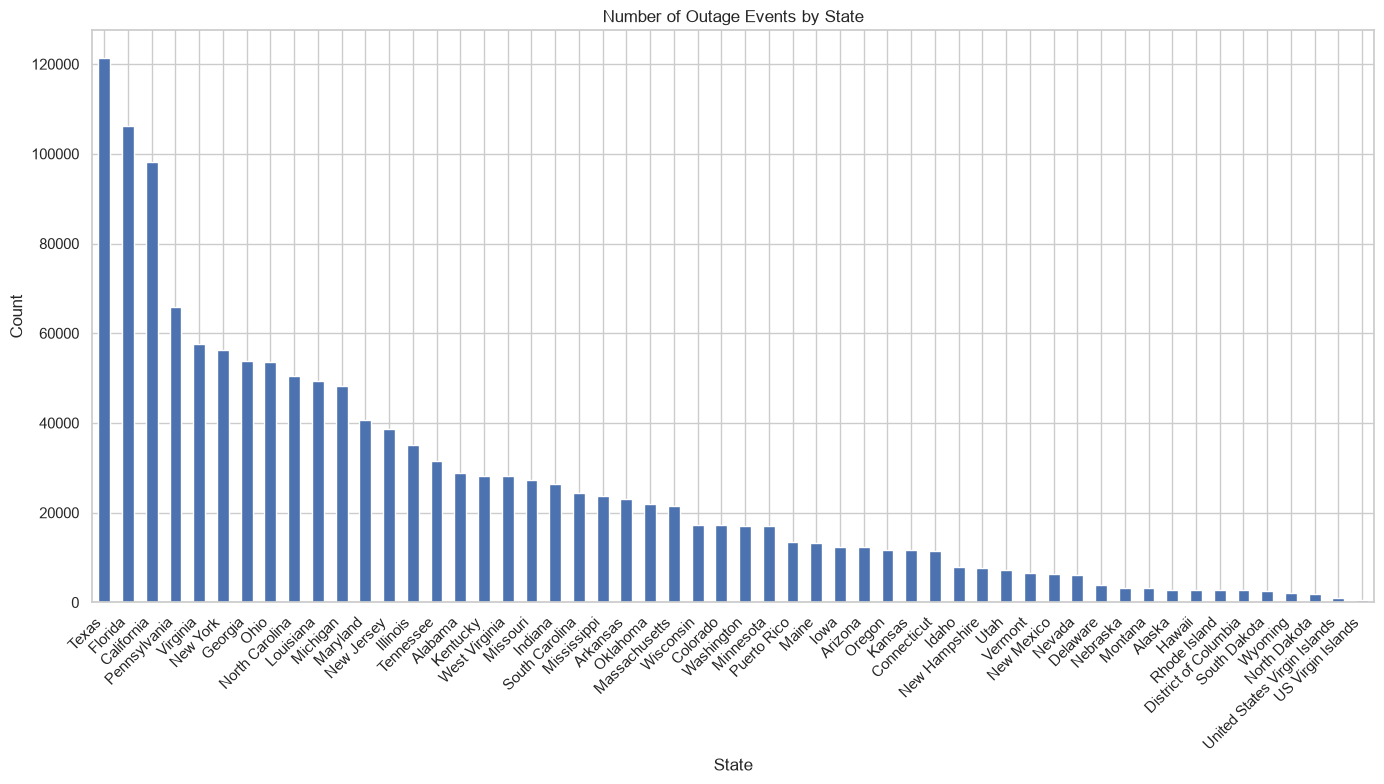

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))
state_counts.plot(kind='bar', ax=ax)
ax.set_title('Number of Outage Events by State')
ax.set_xlabel('State')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## County Frequency (Top 20)

In [8]:
county_counts = df['county'].value_counts()
print(f"Unique counties: {len(county_counts)}")
county_counts.head(20)

Unique counties: 1756


county
Baltimore     23465
Jefferson     19576
Montgomery    16910
Orange        15951
Washington    12635
Miami-Dade    11774
Franklin      11264
Broward        9800
Wayne          9772
Cook           9761
St. Louis      9600
Marion         9489
Middlesex      8710
Jackson        8660
Monroe         8269
Harris         8120
Dallas         8078
Suffolk        7977
Riverside      7449
Palm Beach     7319
Name: count, dtype: int64

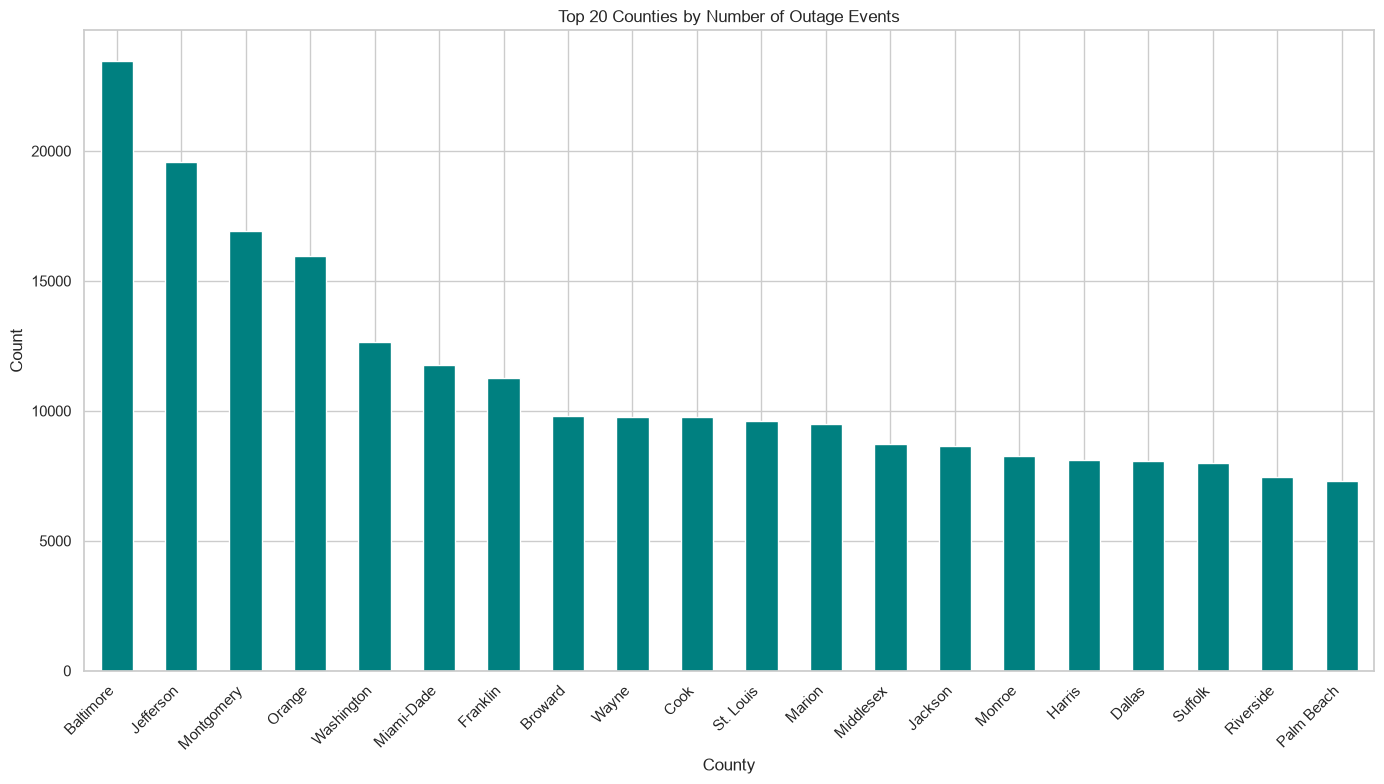

In [9]:
fig, ax = plt.subplots(figsize=(14, 8))
county_counts.head(20).plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 20 Counties by Number of Outage Events')
ax.set_xlabel('County')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## FIPS Code Frequency (Top 20)

In [10]:
fips_counts = df['fips'].value_counts()
print(f"Unique FIPS codes: {len(fips_counts)}")
fips_counts.head(20)

Unique FIPS codes: 2985


fips
24005    11779
12086    11774
24510    11686
12011     9800
17031     9711
48201     7794
6065      7449
12099     7319
6059      7119
6073      7046
48113     7017
6071      6965
4013      6912
42101     6163
48439     6142
6037      6136
12057     5858
6111      5395
47157     5201
26163     5034
Name: count, dtype: int64

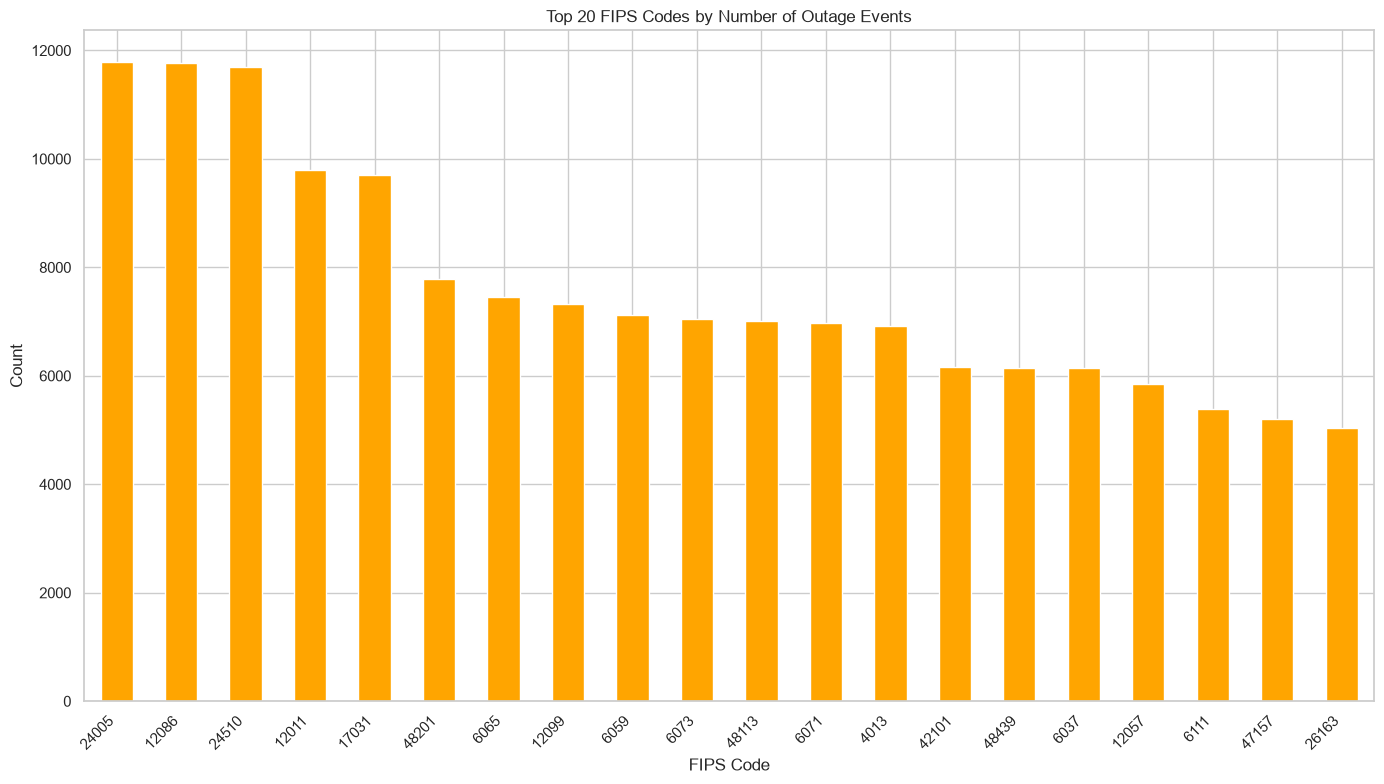

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))
fips_counts.head(20).plot(kind='bar', ax=ax, color='orange')
ax.set_title('Top 20 FIPS Codes by Number of Outage Events')
ax.set_xlabel('FIPS Code')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Duration Distribution

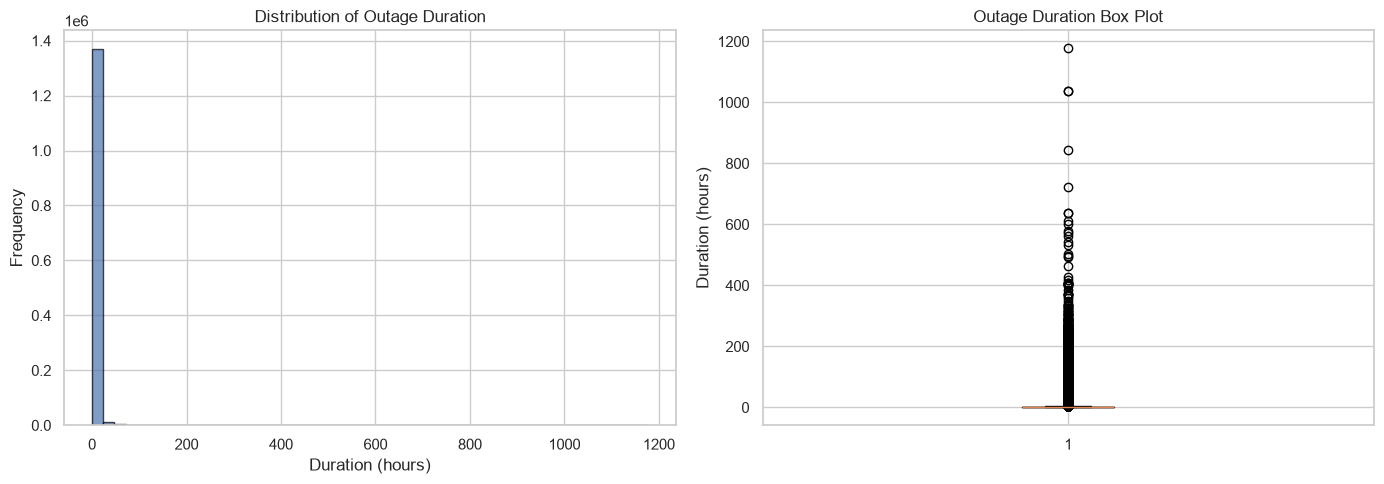

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['duration'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Outage Duration')
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['duration'].dropna())
axes[1].set_title('Outage Duration Box Plot')
axes[1].set_ylabel('Duration (hours)')

plt.tight_layout()
plt.show()

## Min Customers Distribution

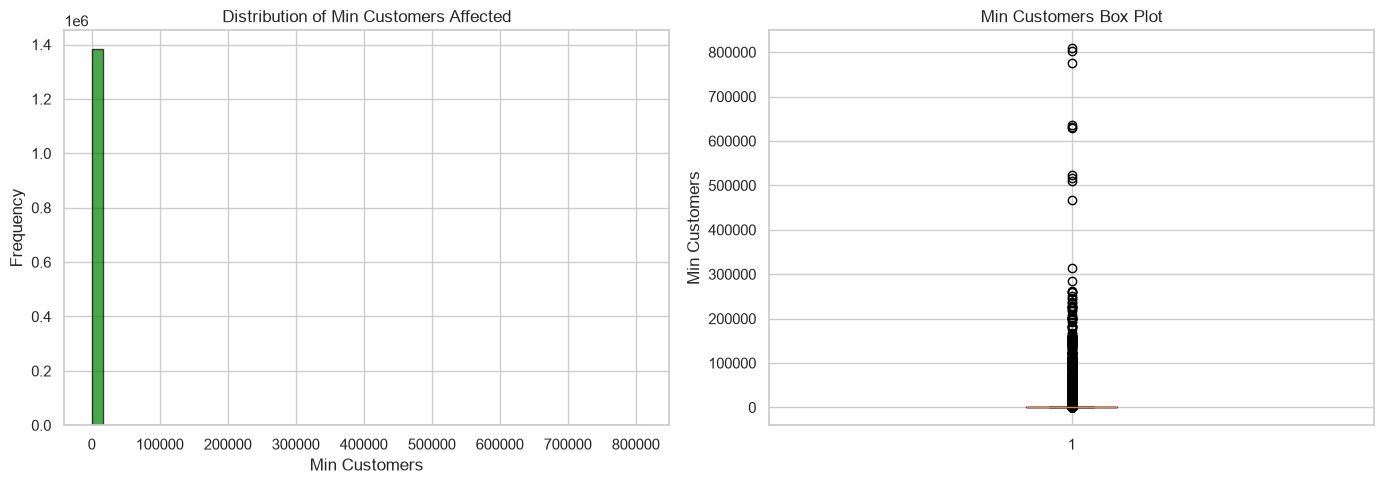

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['min_customers'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].set_title('Distribution of Min Customers Affected')
axes[0].set_xlabel('Min Customers')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['min_customers'].dropna())
axes[1].set_title('Min Customers Box Plot')
axes[1].set_ylabel('Min Customers')

plt.tight_layout()
plt.show()

## Max Customers Distribution

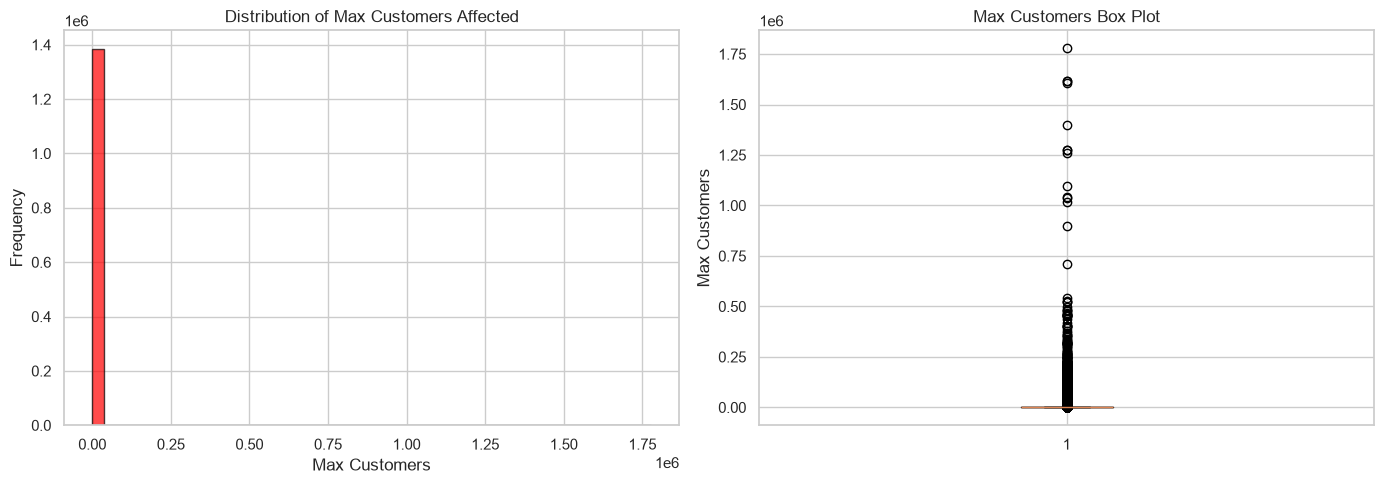

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['max_customers'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[0].set_title('Distribution of Max Customers Affected')
axes[0].set_xlabel('Max Customers')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['max_customers'].dropna())
axes[1].set_title('Max Customers Box Plot')
axes[1].set_ylabel('Max Customers')

plt.tight_layout()
plt.show()

## Mean Customers Distribution

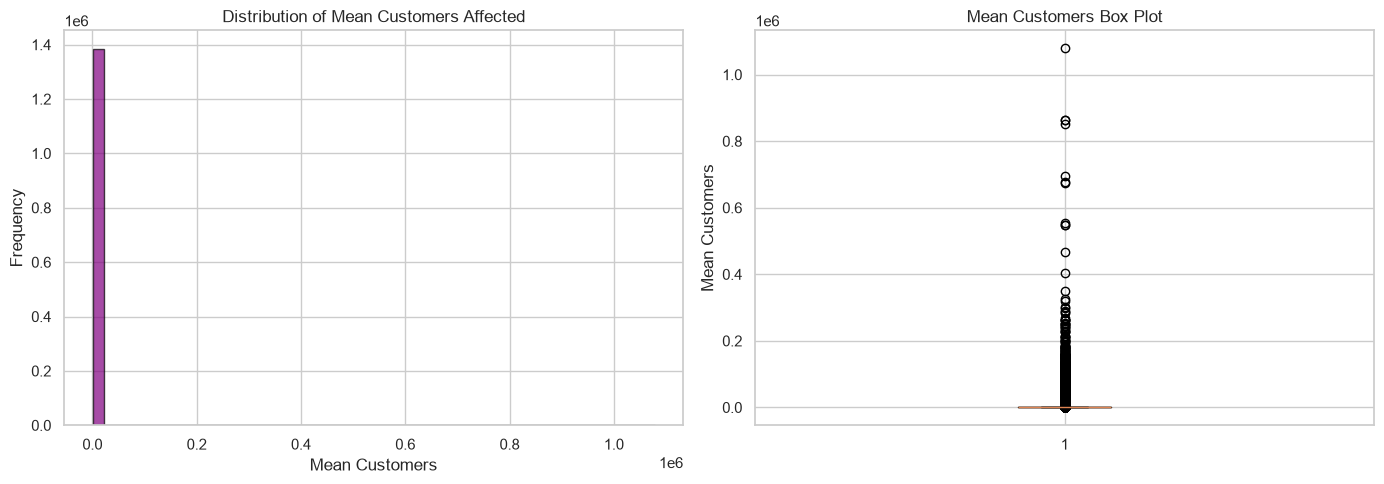

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['mean_customers'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0].set_title('Distribution of Mean Customers Affected')
axes[0].set_xlabel('Mean Customers')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(df['mean_customers'].dropna())
axes[1].set_title('Mean Customers Box Plot')
axes[1].set_ylabel('Mean Customers')

plt.tight_layout()
plt.show()

## Temporal Analysis

In [16]:
# Parse datetime
df['start_time'] = pd.to_datetime(df['start_time'])
df['year'] = df['start_time'].dt.year
df['month'] = df['start_time'].dt.month
df['hour'] = df['start_time'].dt.hour

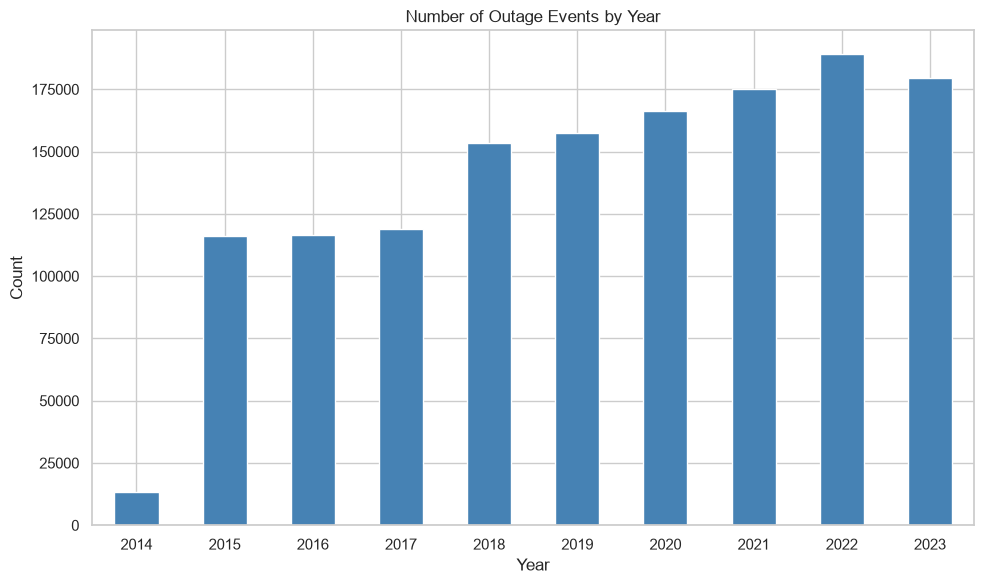

In [17]:
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
year_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of Outage Events by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

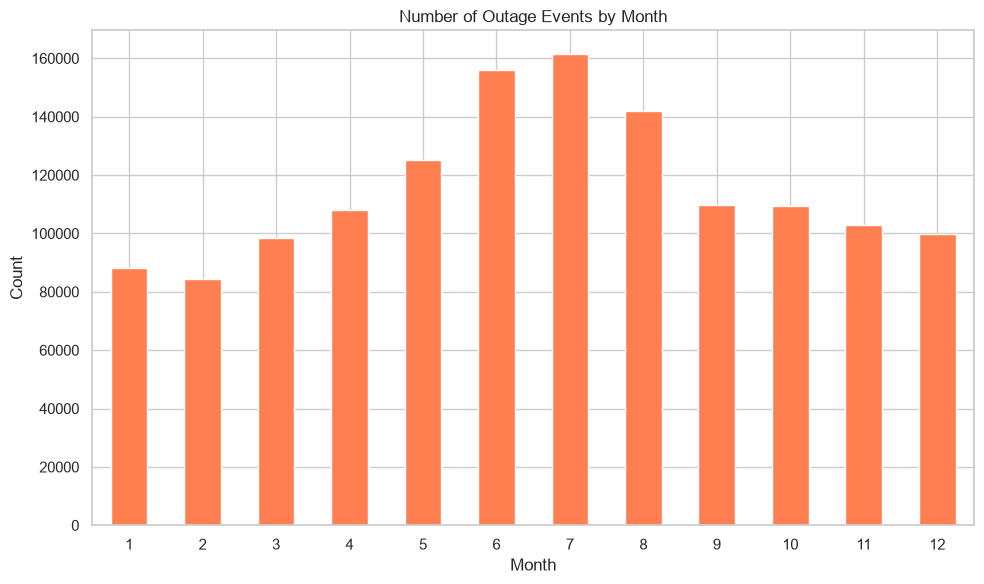

In [18]:
month_counts = df['month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
month_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Number of Outage Events by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

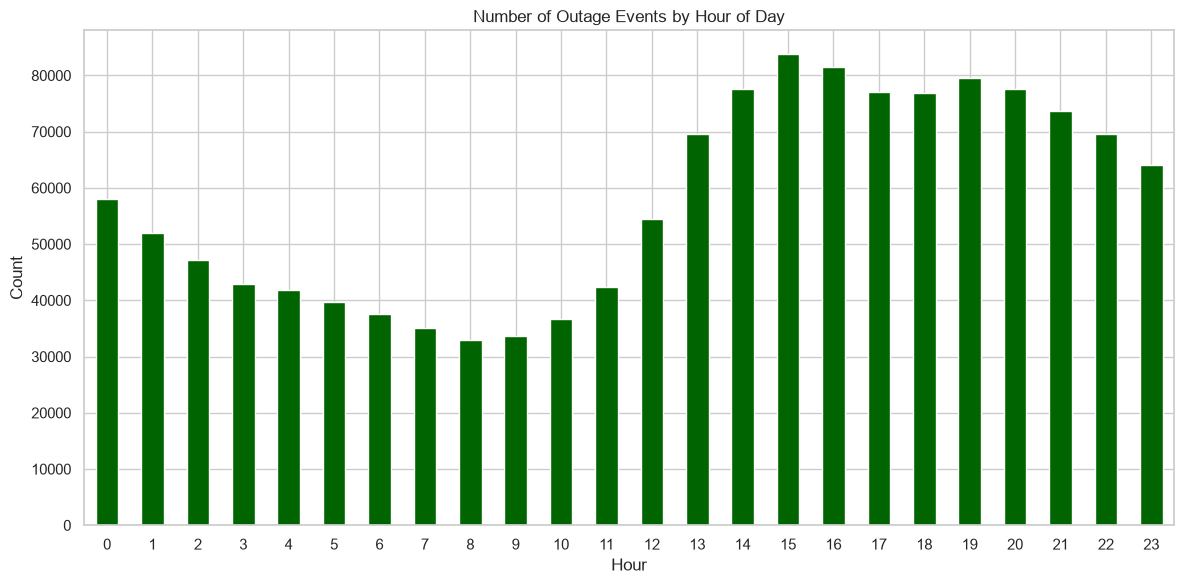

In [19]:
hour_counts = df['hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
hour_counts.plot(kind='bar', ax=ax, color='darkgreen')
ax.set_title('Number of Outage Events by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()